In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv('C:\\Users\\HP\\Desktop\\COFFEE_YIELD_PREDICTION\\coffee_yield_data.csv')

In [ ]:
#Removing extreme values
Q1 = df["Cherry Yield (Kgs)"].quantile(0.25)
Q3 = df["Cherry Yield (Kgs)"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Define target variable (Cherry Yield)
target_col = "Cherry Yield (Kgs)"

# Define features (excluding target variable)
feature_cols = [col for col in df.columns if col != target_col]

# Separate features and target
X = df[feature_cols]
y = df[target_col]


# Remove outliers
df = df[(df["Cherry Yield (Kgs)"] >= lower_bound) & (df["Cherry Yield (Kgs)"] <= upper_bound)]
# Remove rows with extreme values
df_filtered = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

print(f"Original dataset size: {df.shape[0]} rows")
print(f"Dataset size after removing outliers: {df_filtered.shape[0]} rows")

Original dataset size: 384 rows
Dataset size after removing outliers: 384 rows


In [ ]:
# Cap values at lower and upper bounds
df[target_col] = np.clip(df[target_col], lower_bound, upper_bound)

print(f"Outliers have been capped between {lower_bound} and {upper_bound}.")

Outliers have been capped between -18831.9153562114 and 71550.3990841931.


In [ ]:
#Apply log transformation to cherry yield
df["Cherry Yield (Kgs)"] = np.log1p(df["Cherry Yield (Kgs)"])

In [ ]:
#Encode categorical features properly
from sklearn.preprocessing import OneHotEncoder

# Select categorical columns
categorical_cols = ["County", "Grower Type", "Coffee Variety"]

# Apply one-hot encoding
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and add encoded ones
df = df.drop(columns=categorical_cols)
df = pd.concat([df, encoded_df], axis=1)

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [ ]:
print(df.columns)  # Check available column names

Index(['Year', 'Rainfall (mm)', 'Temperature (°C)', 'Soil pH', 'Humidity (%)',
       'CBD Cases', 'CLR Cases', 'BBC Cases', 'Production Cost (KES)',
       'Cherry Payout (KES/kg)', 'Auction Price (USD/50Kg)',
       'Fertilizer Use (Kg/acre)', 'Insecticide Use (Liters/acre)',
       'Fungicide Use (Liters/acre)', 'Labor Cost (KES/acre)',
       'Canopy Management Score', 'Cherry Yield (Kgs)',
       'Parchment Yield (Kgs)', 'Clean Coffee Yield (Kgs)', 'County_Kirinyaga',
       'County_Murang’a', 'County_Nyeri', 'Grower Type_Estate',
       'Coffee Variety_Ruiru 11', 'Coffee Variety_SL28',
       'Coffee Variety_SL34'],
      dtype='object')


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define target variable
target_col = "Cherry Yield (Kgs)"

# Define feature columns (exclude target)
feature_cols = [col for col in df.columns if col != target_col]

# Split data
X = df[feature_cols]
y = df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define XGBoost model
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", enable_categorical=False, random_state=42)

# Define Bayesian search space
param_space = {
    "n_estimators": Integer(50, 500),
    "learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "max_depth": Integer(3, 10),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.5, 1.0)
}

# Bayesian Optimization
bayes_search = BayesSearchCV(
    xgb_model,
    param_space,
    n_iter=30,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

# Fit model
bayes_search.fit(X_train, y_train)

# Best model from tuning
best_xgb_model_bayes = bayes_search.best_estimator_

# Predictions
y_pred_bayes = best_xgb_model_bayes.predict(X_test)

# Evaluate Model
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
mse_bayes = mean_squared_error(y_test, y_pred_bayes)
rmse_bayes = np.sqrt(mse_bayes)
r2_bayes = r2_score(y_test, y_pred_bayes)

# Print Results
print(f"Mean Absolute Error (MAE): {mae_bayes:.2f}")
print(f"Mean Squared Error (MSE): {mse_bayes:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_bayes:.2f}")
print(f"R² Score: {r2_bayes:.2f}")


Mean Absolute Error (MAE): 0.09
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.11
R² Score: 0.96


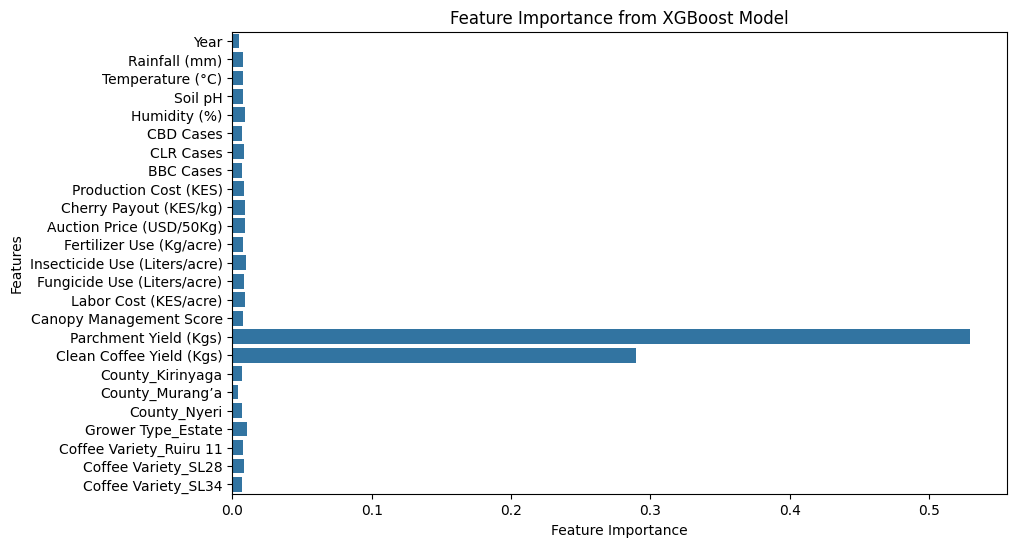

In [ ]:
# Get feature importance from XGBoost model
importance = best_xgb_model_bayes.feature_importances_
feature_names = X_train.columns

#import dependencies
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=feature_names)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance from XGBoost Model")
plt.show()

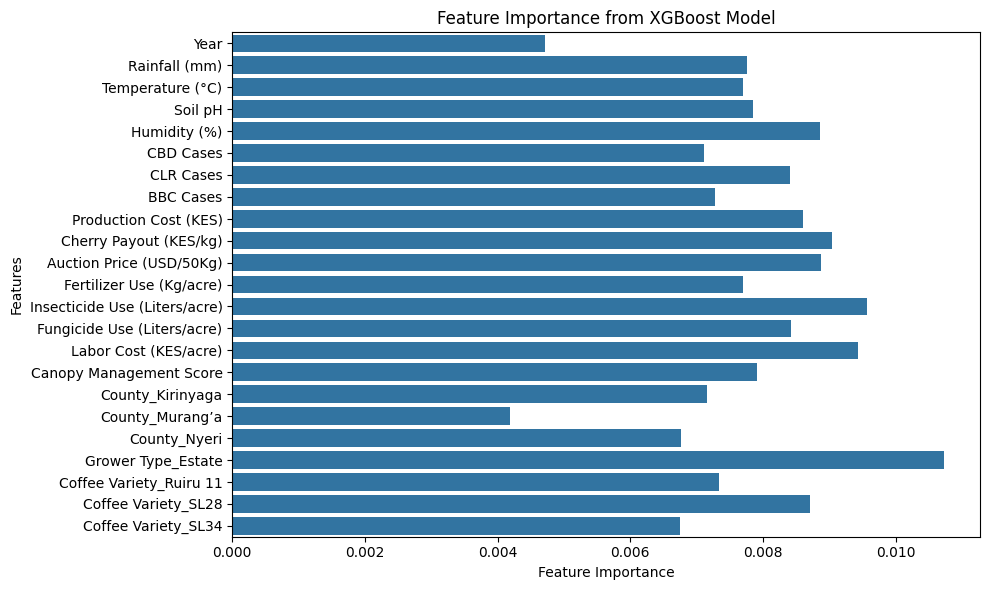

In [ ]:
#exclude yields
excluded = ['Cherry Yield (Kgs)', 'Parchment Yield (Kgs)', 'Clean Coffee Yield (Kgs)']
filtered_features = [(f, i) for f, i in zip(feature_names, importance) if f not in excluded]

#plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=[i for _, i in filtered_features], y=[f for f, _ in filtered_features])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance from XGBoost Model")
plt.tight_layout()
plt.show()



In [ ]:
# Calculate the correlation matrix for the entire dataset
correlation_matrix = df.corr()

# Display full correlation matrix
print(correlation_matrix)

                                       Year  Rainfall (mm)  Temperature (°C)  \
Year                           1.000000e+00      -0.011327         -0.040973   
Rainfall (mm)                 -1.132707e-02       1.000000         -0.126625   
Temperature (°C)              -4.097272e-02      -0.126625          1.000000   
Soil pH                        1.788839e-02       0.091005         -0.039466   
Humidity (%)                   1.732249e-02      -0.007394         -0.088826   
CBD Cases                     -1.459650e-02      -0.030073         -0.023697   
CLR Cases                      5.597593e-02      -0.003214          0.026307   
BBC Cases                     -3.678989e-02      -0.002772          0.045984   
Production Cost (KES)          3.563504e-02       0.085757         -0.012898   
Cherry Payout (KES/kg)         3.530770e-02       0.011071         -0.046946   
Auction Price (USD/50Kg)      -8.266581e-02       0.089484         -0.039559   
Fertilizer Use (Kg/acre)      -4.041553e

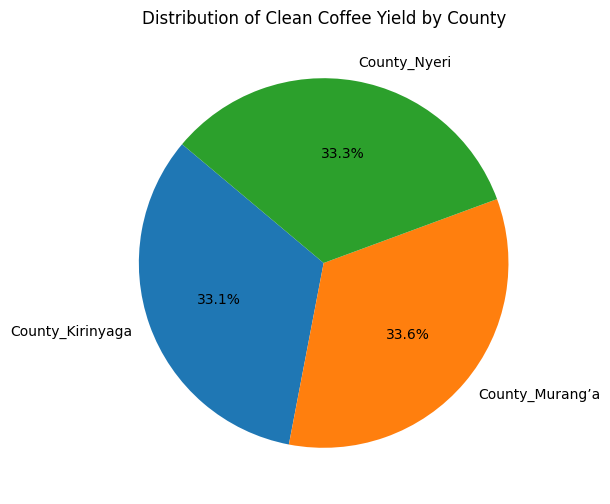

In [ ]:
import matplotlib.pyplot as plt


# Create a list of the counties am interested in
counties = ['County_Kirinyaga', 'County_Murang’a', 'County_Nyeri']

# Calculate the total Clean Coffee Yield for each county
county_clean_coffee_yield = df[counties].apply(lambda x: df['Clean Coffee Yield (Kgs)'][x == 1].sum(), axis=0)

# Pie chart for Clean Coffee Yield by County
plt.figure(figsize=(6, 6))
plt.pie(county_clean_coffee_yield, labels=county_clean_coffee_yield.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Clean Coffee Yield by County')
plt.show()

In [ ]:

# Check the 'Year' column directly to see what data it contains
print(df['Year'].head())



0    2013
1    2013
2    2013
3    2013
4    2013
Name: Year, dtype: int64


In [ ]:
# First, make sure that 'Date' is in datetime format, if it exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Coerce invalid dates to NaT
    df['Year'] = df['Date'].dt.year  # Extract the year
else:
    # If 'Date' column is not there, ensure 'Year' is directly an integer and does not have timestamp-like values
    df['Year'] = df['Year'].astype(int)

# Check the first few rows to make sure 'Year' is fixed
print(df['Year'].head())


0    2013
1    2013
2    2013
3    2013
4    2013
Name: Year, dtype: int64


In [ ]:
# Example of manually fixing year if required
df['Year'] = df['Year'] // 1000000000  # Remove the extra time-related digits

# Check the 'Year' column after fixing it
print(df['Year'].head())

0    0
1    0
2    0
3    0
4    0
Name: Year, dtype: int64


In [ ]:
# Convert the Unix timestamp (seconds since 1970) to datetime
df['Year'] = pd.to_datetime(df['Year'], unit='s').dt.year  # 'unit=s' indicates seconds

# Check the first few rows to ensure it's correct
print(df['Year'].head())


0    1970
1    1970
2    1970
3    1970
4    1970
Name: Year, dtype: int32


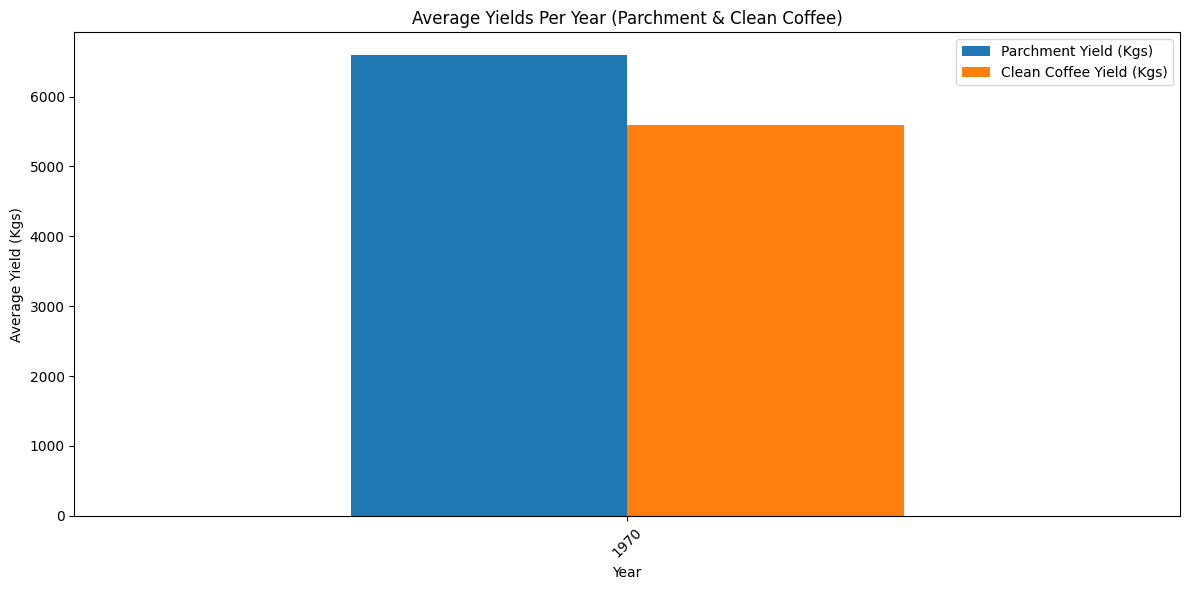

In [ ]:
# Group by 'Year' and calculate the average of Parchment and Clean Coffee Yields only
avg_yields_per_year = df.groupby('Year')[['Parchment Yield (Kgs)', 'Clean Coffee Yield (Kgs)']].mean()

# Plot the average yields per year for Parchment and Clean Coffee only
avg_yields_per_year.plot(kind='bar', figsize=(12, 6))  # 'bar' for vertical bars
plt.title("Average Yields Per Year (Parchment & Clean Coffee)")
plt.xlabel("Year")
plt.ylabel("Average Yield (Kgs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

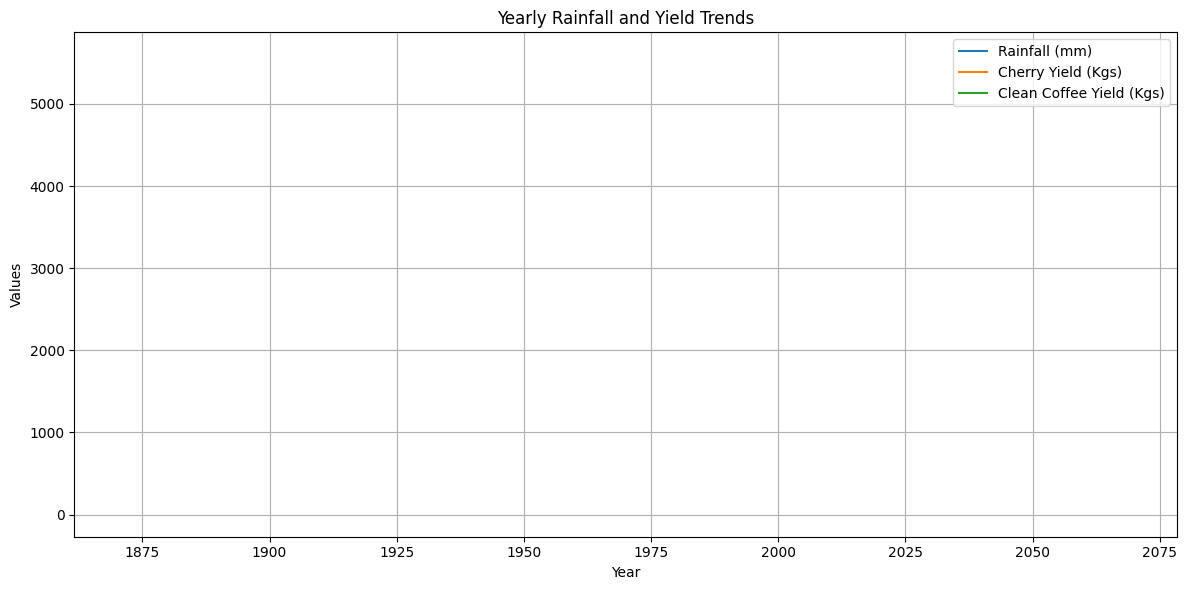

In [ ]:
# Ensure 'Year' is in datetime format
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Group by year and calculate average rainfall and yield
yearly_data = df.groupby(df['Year'].dt.year)[['Rainfall (mm)', 'Cherry Yield (Kgs)', 'Clean Coffee Yield (Kgs)']].mean()

# Plot line graph
yearly_data.plot(figsize=(12, 6))
plt.title('Yearly Rainfall and Yield Trends')
plt.xlabel('Year')
plt.ylabel('Values')
plt.grid(True)
plt.tight_layout()
plt.show()


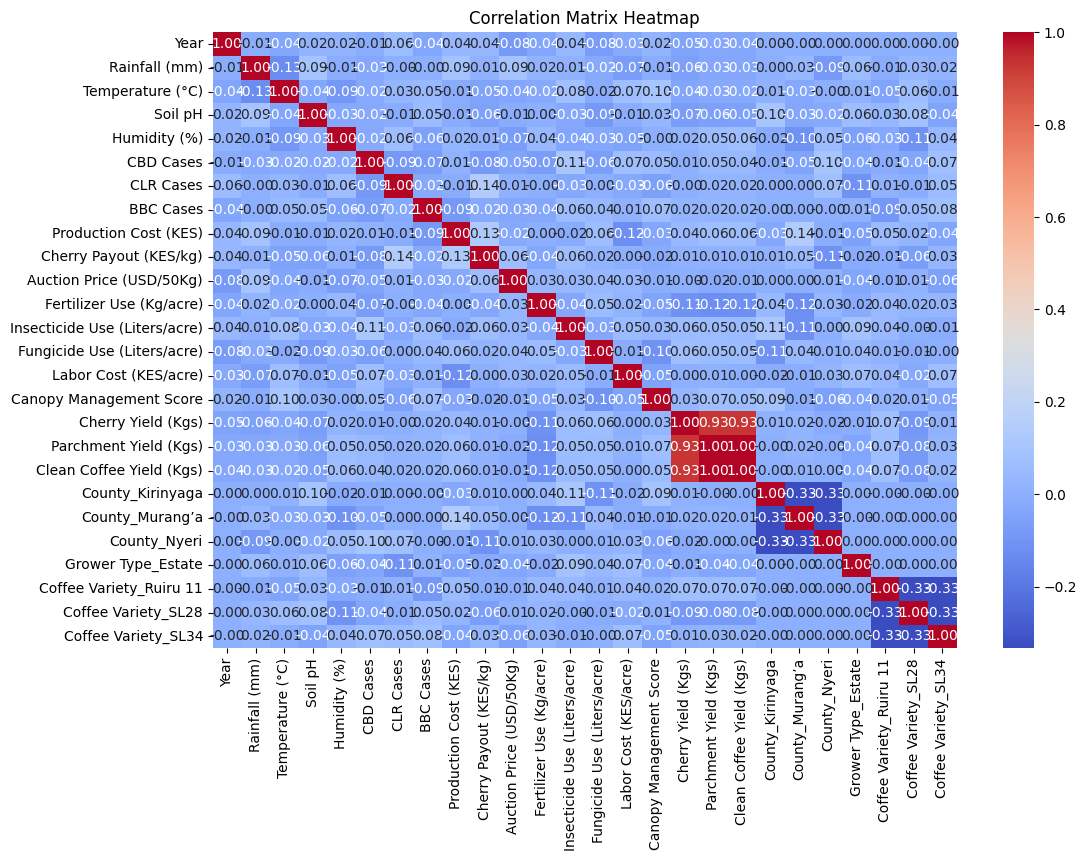

In [ ]:
import seaborn as sns

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


In [ ]:
import joblib

# Save the model
joblib.dump(best_xgb_model_bayes, 'best_xgb_model_bayes.pkl')
print("Model saved successfully as 'best_xgb_model_bayes.pkl'")


Model saved successfully as 'best_xgb_model_bayes.pkl'


In [ ]:
import os

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\HP\Desktop\COFFEE_YIELD_PREDICTION


In [ ]:
print(df.columns.tolist())


['Year', 'Rainfall (mm)', 'Temperature (°C)', 'Soil pH', 'Humidity (%)', 'CBD Cases', 'CLR Cases', 'BBC Cases', 'Production Cost (KES)', 'Cherry Payout (KES/kg)', 'Auction Price (USD/50Kg)', 'Fertilizer Use (Kg/acre)', 'Insecticide Use (Liters/acre)', 'Fungicide Use (Liters/acre)', 'Labor Cost (KES/acre)', 'Canopy Management Score', 'Cherry Yield (Kgs)', 'Parchment Yield (Kgs)', 'Clean Coffee Yield (Kgs)', 'County_Kirinyaga', 'County_Murang’a', 'County_Nyeri', 'Grower Type_Estate', 'Coffee Variety_Ruiru 11', 'Coffee Variety_SL28', 'Coffee Variety_SL34']
